#Introduction
The goal is to teach a robotic arm to move its gripper to a target point in space. <br>
First we set up the FetchReach environment. <br>
We evaluate a proportional controller as a simple baseline in the dense-reward environment. <br>
We train DDPG in the unmodified environment and confirm it learns the task. <br>
Next we modify the environment by adding sparse rewards and Gaussian observation noise. <br>
We evaluate the proportional controller again to measure the impact of these changes. <br>
We train DDPG in the modified environment and observe that it fails to learn a stable policy. <br>
We then train TD3, which succeeds under the modified conditions. <br>
Finally, we combine TD3 with HER, which learns the task even faster and more reliably.<br>
The notebook is availble on google colab at: https://colab.research.google.com/drive/1rTvmWUAx0gP1GcQdDxyQkA1spcM0OSde?usp=sharing

#Setup Environemnt

Mujoco is high-performance physics engine. <br>
Force, friction, 3d rendering ... <br>

In [ ]:
!pip install mujoco

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 106.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 20.7 MB/s eta 0:00:00


Gymnasuim provide core functions for RL environment. <br>

In [ ]:
!pip install gymnasium

Gymansuim robotics is a libary of robotics environment built on top of Gymnasium using Mujoco for physics.

In [ ]:
!pip install gymnasium-robotics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.2/26.2 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.5/852.5 kB 59.3 MB/s eta 0:00:00


Stable-baseline contains implmented algorithms PPO, SAC, DDPG, TD3.

In [ ]:
!pip install stable-baselines3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.2/187.2 kB 14.6 MB/s eta 0:00:00


Mujoco normally requires a real monitor. <br>
OSMesa (Off-Screen Mesa) libary is a CPU-based OpenGL render that work without a window. <br>
Used since Colab has no display.




In [ ]:
!apt-get install -y libosmesa6-dev

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libdrm-dev libgl-dev libglx-dev libosmesa6 libpciaccess-dev mesa-common-dev
The following NEW packages will be installed:
  libdrm-dev libgl-dev libglx-dev libosmesa6 libosmesa6-dev libpciaccess-dev
  mesa-common-dev
0 upgraded, 7 newly installed, 0 to remove and 41 not upgraded.
Need to get 5,761 kB of archives.
After this operation, 18.5 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libpciaccess-dev amd64 0.16-3 [21.9 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libdrm-dev amd64 2.4.113-2~ubuntu0.22.04.1 [292 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 libglx-dev amd64 1.4.0-1 [14.1 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/main amd64 libgl-dev amd64 1.4.0-1 [101 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 mesa-com

Mujoco include pre-compiled .so files. <br>
These files contain hard-coded paths to OpenGL/EGL libraries.  <br>
These paths need to be rewritten for google colab. <br>
Pip uses patchelf behind the scenes.

In [ ]:
!apt-get install -y patchelf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  patchelf
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 72.1 kB of archives.
After this operation, 186 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 patchelf amd64 0.14.3-1 [72.1 kB]
Fetched 72.1 kB in 1s (72.8 kB/s)
Selecting previously unselected package patchelf.
(Reading database ... 122264 files and directories currently installed.)
Preparing to unpack .../patchelf_0.14.3-1_amd64.deb ...
Unpacking patchelf (0.14.3-1) ...
Setting up patchelf (0.14.3-1) ...
Processing triggers for man-db (2.10.2-1) ...


Import all necessary libaries.

In [ ]:
import gymnasium as gym
from gymnasium import Wrapper    # to add gaussian noise to end effector
import gymnasium_robotics
import mujoco   # physics environemnt
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from stable_baselines3.common.monitor import Monitor  # so we can monitor succes
from stable_baselines3 import DDPG
from stable_baselines3 import TD3
from stable_baselines3.common.noise import NormalActionNoise     # action noise for DDPG exploration
from stable_baselines3.her.her_replay_buffer import HerReplayBuffer    #HER replay buffer
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator   # for accessing the graphs generated through tensorboard

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Tell Mujoco which rendering backend to use.
EGL is GPU offscreen. <br>
Tell EGL which GPU to use. <br>

In [ ]:
os.environ["MUJOCO_GL"] = "egl"
os.environ["EGL_DEVICE_ID"] = "0"

Create the environment. <br>
Reset the evniornemnt. <br>


In [ ]:
env = gym.make("FetchReach-v4", render_mode="rgb_array", reward_type="dense")    # monitor if its a success and the distance to the goal
obs, info = env.reset()

Get a frame from the environment and display it.

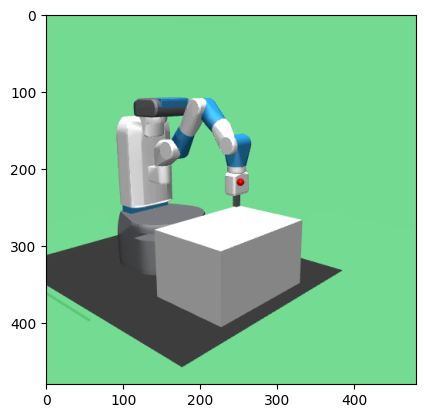

In [ ]:
frame = env.render()
plt.imshow(frame)

**Observation keys contains:** <br>
observation: robot internal state  <br>
achieved goal: current 3-D position of the robot gripper. <br>
desired goal: 3-D target position gripper needs to reach. <br>

**Observation space:** <br>
Dictionary with three parts   <br>
achieved goal: (x,y,z)  <br>
desired_goal:  (x,y,z)  <br>
observation: 10 values:  <br>
1–3. Gripper position (x, y, z)  <br>
4–6. Gripper linear velocity (vx, vy, vz) <br>
7–9. Finger_left_pos, Finger_right_pos, combined finger coordinate. Fingers do not matter for us. <br>
10. Finger velocity. Fingers do not matter for us. <br>

**Action space contains:** <br>
4 seperate actions values each one is a float.  
1. Δx: move gripper left or right. <br>
2. Δy: move gripper forward or backward.  <br>
3. Δz: move gripper up or down.   <br>
4. Gripper open/close control: positive open, negative closed. Dont use the gripper, so this value doesnt matter.

In [ ]:
print("Observation keys:", obs.keys())
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

Observation keys: dict_keys(['observation', 'achieved_goal', 'desired_goal'])
Observation space: Dict('achieved_goal': Box(-inf, inf, (3,), float64), 'desired_goal': Box(-inf, inf, (3,), float64), 'observation': Box(-inf, inf, (10,), float64))
Action space: Box(-1.0, 1.0, (4,), float32)


#Heuristic Baseline with Unmodified Environment



We implement a simple proportional controller to use as a a basline.

In [ ]:
def proportional_controller(obs_dict, kp=5.0):
  position = obs_dict["observation"][0:3] # Current end-effector position (x, y, z)
  goal = obs_dict["desired_goal"]   # Target position
  action_xyz = kp * (goal - position)   # action needed to move towards the goal
  action = np.concatenate([action_xyz, [0.0]])    #4th action is gripper control, which we dont need
  action = np.clip(action, -1, 1)   # clip to valid action space
  return action

We implement an evaluation function.

In [ ]:
def evaluate_policy(env, policy_fn, episodes=10):
    success_count = 0
    final_distances = []

    for ep in range(episodes):
        obs_dict, info = env.reset()
        done = False

        while not done:
            action = policy_fn(obs_dict)    # run the policy
            obs_dict, reward, terminated, truncated, info = env.step(action)    # run the action
            done = terminated or truncated

        # Compute final Euclidean distance
        achieved = obs_dict["achieved_goal"]
        desired  = obs_dict["desired_goal"]
        dist = np.linalg.norm(achieved - desired)
        final_distances.append(dist)

        # check if success
        success_count += info.get("is_success", 0)

    avg_success  = success_count / episodes
    avg_distance = np.mean(final_distances)

    print(f"Success rate: {avg_success * 100:.1f}%, Average distance: {avg_distance:.2f}")

    return avg_success, avg_distance

Now lets use the function to evalute proportional controller.

In [ ]:
success, avg_distance = evaluate_policy(env, lambda obs: proportional_controller(obs, kp=1))

Success rate: 100.0%, Average distance: 0.03


#DDPG with Unmodified Environment

Create the environment.

In [ ]:
env = gym.make("FetchReach-v4", render_mode="rgb_array", reward_type="dense")

Since FetchReach is deterministic, noise is required for exploration. <br>
Without noise, agent would never explore, so training would fail. <br>
We use a Gaussian noise generator.

In [ ]:
def make_action_noise(env, sigma=0.1):
    n_actions = env.action_space.shape[-1]
    return NormalActionNoise(
        mean=np.zeros(n_actions),     #  Our mean noise is zero, so no directional bias. [0,0,0,0]
        sigma=sigma * np.ones(n_actions)    # Our mean standard deviation is 0.1. [0.1,0.1,0.1,0.1]
    )

Now we create the DDPG model.

In [ ]:
model = DDPG(
    policy="MultiInputPolicy",   # since we have dict observations
    env=env,
    action_noise=make_action_noise(env),    # use the gaussian noise for exploration
    learning_rate=1e-3,
    buffer_size=100000,      # replay buffer capacity
    batch_size=256,          # minibatch size
    tau=0.005,          # use to update target network, target = (1 - tau) * target + tau * main
    gamma=0.98,     # discount factor (how much agent cares about future rewards)
    tensorboard_log="./tensorboard/ddpg_unmodified_env/" ,  # gives you reward curve, success curve, actor/critic loss
    verbose=1,          # print training process
)

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Now we train the DDPG model.

In [ ]:
model.learn(total_timesteps=100000)
model.save("DDPG_unmodified")

Streaming output truncated to the last 5000 lines.
|    time_elapsed    | 360      |
|    total_timesteps | 37600    |
| train/             |          |
|    actor_loss      | 0.446    |
|    critic_loss     | 0.000124 |
|    learning_rate   | 0.001    |
|    n_updates       | 37499    |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -0.913   |
|    success_rate    | 1        |
| time/              |          |
|    episodes        | 756      |
|    fps             | 104      |
|    time_elapsed    | 361      |
|    total_timesteps | 37800    |
| train/             |          |
|    actor_loss      | 0.479    |
|    critic_loss     | 8.54e-05 |
|    learning_rate   | 0.001    |
|    n_updates       | 37699    |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -0.906  

Now evalute DDPG.

In [ ]:
eval_env = gym.make("FetchReach-v4", render_mode="rgb_array",reward_type="dense")

# Load the trained model
model = DDPG.load("DDPG_unmodified", env=eval_env)

success, avg_distance = evaluate_policy(
    eval_env,
    lambda obs: model.predict(obs, deterministic=True)[0],   # returns only the action
    episodes=10
)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Success rate: 100.0%, Average distance: 0.03


In [ ]:
%load_ext tensorboard
%tensorboard --logdir ./tensorboard/ddpg_unmodified_env/

#Environment Modification

We will modify the envrionment in two ways. <br>
1. use sparse rewards. <br>
-1 if the end effector hasn’t reached its final target position. <br>
0 if the end effector is in the final target position.  <br>
2. Add Gausian noise to end effector observation. <br>
We do this using a wrapper.

In [ ]:
class ObservationNoiseWrapper(gym.ObservationWrapper):
    def __init__(self, env, noise_std=0.01):
        super().__init__(env)
        self.noise_std = noise_std

    def observation(self, obs):
        # Copy observation to avoid modifying original
        noisy_obs = obs.copy()

        # Add Gaussian noise to end-effector position: obs["observation"][0:3]
        noise = np.random.normal(0, self.noise_std, size=3)
        noisy_obs["observation"][0:3] += noise

        return noisy_obs

In [ ]:
def make_modified_env(noise_std=0.15, reward_type="sparse", log_dir=None):
    env = gym.make(
        "FetchReach-v4",
        render_mode="rgb_array",
        reward_type=reward_type      #1. make it spares
    )
    env = ObservationNoiseWrapper(env, noise_std=noise_std)   # 2. add gausian noise
    if log_dir is not None:
        env = Monitor(env, log_dir, info_keywords=("is_success",))
    else:
        env = Monitor(env, info_keywords=("is_success",))
    return env

#Heuristic Baseline with Modified Environment

In [ ]:
env = make_modified_env()
success, avg_distance = evaluate_policy(
    env,
    lambda obs: proportional_controller(obs, kp=1.0),
    episodes=20
)

Success rate: 75.0%, Average distance: 0.04


# DDPG with Modified Environment

In [ ]:
train_env = make_modified_env(log_dir="./logs/DDPG/")   # create the environment

ddpg_model = DDPG(     # setup the model
    policy="MultiInputPolicy",
    env=train_env,
    action_noise=make_action_noise(env),
    learning_rate=1e-3,
    buffer_size=100000,
    batch_size=256,
    tau=0.005,
    gamma=0.98,
    tensorboard_log="./tensorboard/DDPG/",
    verbose=1
)

# Train
ddpg_model.learn(total_timesteps=100000)

# Save the trained model
ddpg_model.save("DDPG")

Streaming output truncated to the last 5000 lines.
|    time_elapsed    | 371      |
|    total_timesteps | 37600    |
| train/             |          |
|    actor_loss      | 46.1     |
|    critic_loss     | 0.0176   |
|    learning_rate   | 0.001    |
|    n_updates       | 37499    |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -49.9    |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 756      |
|    fps             | 101      |
|    time_elapsed    | 373      |
|    total_timesteps | 37800    |
| train/             |          |
|    actor_loss      | 46.1     |
|    critic_loss     | 0.0315   |
|    learning_rate   | 0.001    |
|    n_updates       | 37699    |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -49.9   

In [ ]:
%load_ext tensorboard
%tensorboard --logdir ./tensorboard/DDPG/

Now we will evalute the DDPG model trained in the modified environment.

In [ ]:
eval_env = make_modified_env()

model = DDPG.load("DDPG", env=eval_env)

success, avg_distance = evaluate_policy(
    eval_env,
    lambda obs: model.predict(obs, deterministic=True)[0],
    episodes=20
)

Wrapping the env in a DummyVecEnv.
Success rate: 65.0%, Average distance: 0.04


#TD3 with Modified Environment

TD3 adds 3 upgrades to DDPG.
1. Uses two critics, to prevent overestimation.
2. Dealyed actor updates, so critic can stabilize.
3. Add Gaussian noise to target action, smooths the learned Q function.

In [ ]:
train_env = make_modified_env(log_dir="./logs/TD3/")

TD3_model = TD3(     # setup the model
    policy="MultiInputPolicy",
    env=train_env,
    action_noise=make_action_noise(env),
    learning_rate=1e-3,
    buffer_size=100000,
    batch_size=256,
    tau=0.005,
    gamma=0.98,
    tensorboard_log="./tensorboard/TD3/",
    verbose=1
)

# Train
TD3_model.learn(total_timesteps=100000)

# Save the trained model
TD3_model.save("TD3")

Streaming output truncated to the last 5000 lines.
|    time_elapsed    | 346      |
|    total_timesteps | 37600    |
| train/             |          |
|    actor_loss      | 42.1     |
|    critic_loss     | 0.0123   |
|    learning_rate   | 0.001    |
|    n_updates       | 37499    |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -49.8    |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 756      |
|    fps             | 108      |
|    time_elapsed    | 347      |
|    total_timesteps | 37800    |
| train/             |          |
|    actor_loss      | 42.3     |
|    critic_loss     | 0.0331   |
|    learning_rate   | 0.001    |
|    n_updates       | 37699    |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -49.8   

In [ ]:
%load_ext tensorboard
%tensorboard --logdir ./tensorboard/TD3/

Now we will evalute the TD3 model

In [ ]:
eval_env = make_modified_env()     # create evaluation envionremnt

model = TD3.load("TD3", env=eval_env)

success, avg_distance = evaluate_policy(
    eval_env,
    lambda obs: model.predict(obs, deterministic=True)[0],
    episodes=20
)

Wrapping the env in a DummyVecEnv.
Success rate: 100.0%, Average distance: 0.02


#TD3 with HER with Modified Environment

Hindsight Experience Replay solves sparse-reward problems. <br>
HER fixes this by pretending that whatever the robot reached later in the episode was actually the goal. <br>
HER picks using episode, final, future strategy. <br>
Episode: Choose ANY achieved goal from anywhere inside the episode.  <br>
Final: Choose ONLY the achieved goal at the last timestep. <br>
Future: For a transition at time t, choose any achieved goal from a later time step. <br>

In [ ]:
train_env = make_modified_env(log_dir="./logs/TD3_HER/")

TD3_HER_model = TD3(
    policy="MultiInputPolicy",
    env=train_env,

    # ---- HER integration ----
    replay_buffer_class=HerReplayBuffer,
    replay_buffer_kwargs=dict(
        n_sampled_goal=4,              # HER ratio (4 HER samples per real transition)
        goal_selection_strategy="future",  # best choice for FetchReach
    ),
    # --------------------------

    action_noise=make_action_noise(env),
    learning_rate=1e-3,
    buffer_size=1000000,       # HER benefits from larger buffer
    batch_size=256,
    tau=0.005,
    gamma=0.98,
    tensorboard_log="./tensorboard/TD3_HER/",
    verbose=1
)

TD3_HER_model.learn(total_timesteps=100000)
TD3_HER_model.save("TD3_HER")

Streaming output truncated to the last 5000 lines.
|    time_elapsed    | 444      |
|    total_timesteps | 37600    |
| train/             |          |
|    actor_loss      | 1.5      |
|    critic_loss     | 0.0544   |
|    learning_rate   | 0.001    |
|    n_updates       | 37499    |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -2.27    |
|    success_rate    | 0.99     |
| time/              |          |
|    episodes        | 756      |
|    fps             | 84       |
|    time_elapsed    | 446      |
|    total_timesteps | 37800    |
| train/             |          |
|    actor_loss      | 1.31     |
|    critic_loss     | 0.0483   |
|    learning_rate   | 0.001    |
|    n_updates       | 37699    |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -2.3    

In [ ]:
%load_ext tensorboard
%tensorboard --logdir ./tensorboard/TD3_HER/

Now we will evalute the TD3 with HER model.

In [ ]:
eval_env = make_modified_env()

model = TD3.load("TD3_HER", env=eval_env)

success, avg_distance = evaluate_policy(
    eval_env,
    lambda obs: model.predict(obs, deterministic=True)[0],
    episodes=20
)

Wrapping the env in a DummyVecEnv.
Success rate: 100.0%, Average distance: 0.02


#Succes Rate Comparison

Now we combine the success rate graphs for DDPG, TD3, and TD3+HER.

First collect all the success rate graphs from tensorboard.

In [ ]:
ROOT = "./tensorboard"

runs = {
    "DDPG"    : f"{ROOT}/DDPG/DDPG_1",
    "TD3"     : f"{ROOT}/TD3/TD3_1",
    "TD3_HER" : f"{ROOT}/TD3_HER/TD3_1",
}

Function to reads TensorBoard log directory and extracts the success rate curve.

In [ ]:
def load_success_rate(logdir):
    ea = EventAccumulator(logdir)
    ea.Reload()
    tag = "rollout/success_rate"

    events = ea.Scalars(tag)
    steps = [e.step for e in events]
    values = [e.value for e in events]

    return steps, values

Plot the training success-rate curves for DDPG, TD3, and TD3+HER.

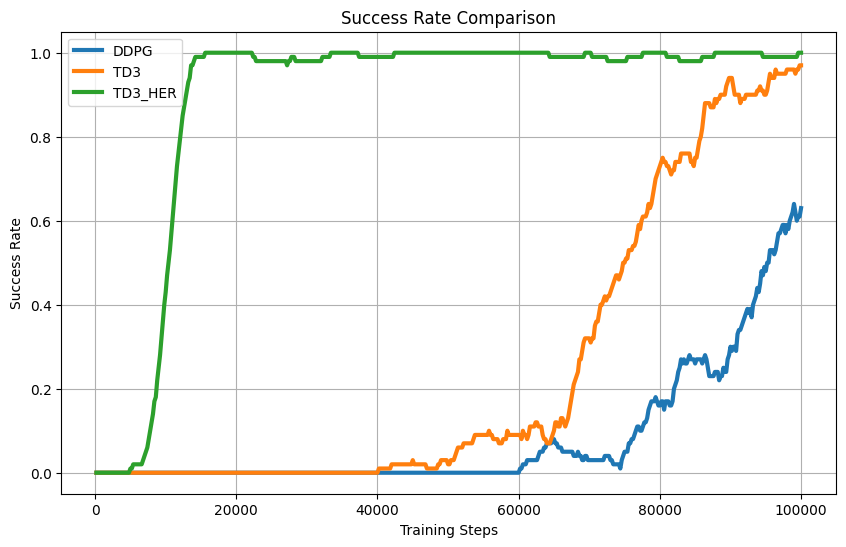

In [ ]:
plt.figure(figsize=(10, 6))

for name, path in runs.items():
    if not os.path.exists(path):
        print(f"Missing directory: {path}")
        continue

    steps, values = load_success_rate(path)
    plt.plot(steps, values, linewidth=3, label=name)

plt.title("Success Rate Comparison")
plt.xlabel("Training Steps")
plt.ylabel("Success Rate")
plt.legend()
plt.grid(True)
plt.show()

#Reward Comparison

First define a moving average function, since raw episode rewards are extremely noisy.

In [ ]:
def moving_average(x, window=50):
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode="valid")

Define a function to load the monitor.csv generated during training of each model.

In [ ]:
def load_rewards(log_dir):
    # Find the monitor.csv file
    files = [f for f in os.listdir(log_dir) if f.endswith(".csv")]
    if len(files) == 0:
        raise FileNotFoundError(f"No monitor CSV file found in {log_dir}")

    path = os.path.join(log_dir, files[0])

    # Monitor CSV has a JSON metadata line at row 0
    df = pd.read_csv(path, skiprows=1)

    rewards = df["r"].values
    lengths = df["l"].values
    timesteps = np.cumsum(lengths)

    # Smooth reward curve
    rewards_smoothed = moving_average(rewards, window=50)
    timesteps_smoothed = timesteps[-len(rewards_smoothed):]   # so the timesetps align with the smoothed rewards

    return timesteps_smoothed, rewards_smoothed

Put together the reward for each model.

In [ ]:
paths = {
    "DDPG": "./logs/DDPG/",
    "TD3": "./logs/TD3/",
    "TD3+HER": "./logs/TD3_HER/"
}

reward_curves = {}
for name, path in paths.items():
    try:
        t, r = load_rewards(path)
        reward_curves[name] = (t, r)
    except Exception as e:
        print(f"Could not load {name}: {e}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Now plot the smoothed reward curves.

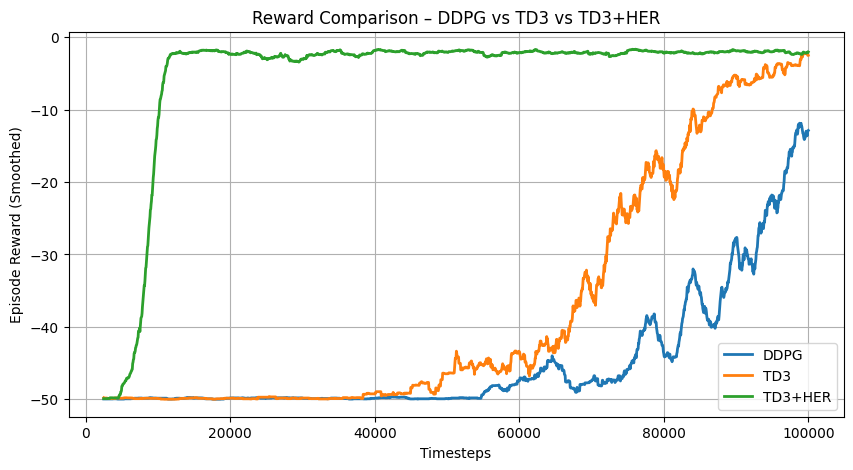

In [ ]:
plt.figure(figsize=(10, 5))

for name, (t, r) in reward_curves.items():
    plt.plot(t, r, linewidth=2, label=name)

plt.xlabel("Timesteps")
plt.ylabel("Episode Reward (Smoothed)")
plt.title("Reward Comparison – DDPG vs TD3 vs TD3+HER")
plt.grid(True)
plt.legend()
plt.show()

#Convergence Comparison

We assume agent has converged when it achieves 80% of the total improvement.

Define a function that determines when convergence occured.

In [ ]:
def detect_convergence(timesteps_smoothed, rewards_smoothed):
    R_min = np.min(rewards_smoothed)
    R_max = np.max(rewards_smoothed)

    threshold = R_min + 0.8 * (R_max - R_min)

    indices = np.where(rewards_smoothed >= threshold)[0]

    if len(indices) == 0:
        return None
    else:
        return int(timesteps_smoothed[indices[0]])

Detect converge for each of the 3 models.

In [ ]:
paths = {
    "DDPG": "./logs/DDPG/",
    "TD3": "./logs/TD3/",
    "TD3+HER": "./logs/TD3_HER/"
}

for name, path in paths.items():
    try:
        t, r = load_rewards(path)
        conv_step = detect_convergence(t, r)

        if conv_step is None:
            print(f"{name}: No convergence detected.")
        else:
            print(f"{name}: Converges at {conv_step} timesteps.")

    except Exception as e:
        print(f"{name}: Error processing logs — {e}")

DDPG: Convergence at 96700 timesteps.
TD3: Convergence at 83750 timesteps.
TD3+HER: Convergence at 10050 timesteps.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Distance Comparison

Now compare the final distance to the goal for DDPG, TD3, and TD3+HER.

Create a function that runs several episodes with a model and returns a list of the final distances between the robots achieved goal and the desired goal for each episode.

In [ ]:
def gather_distances(model, env_fn, episodes=50):
    dists = []
    env = env_fn()

    for _ in range(episodes):
        obs, info = env.reset()
        done = False

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

        # Final Euclidean distance between achieved and desired goal
        dist = np.linalg.norm(
            obs["achieved_goal"] - obs["desired_goal"]
        )
        dists.append(dist)

    return dists

Load the models.

In [ ]:
ddpg_mod = DDPG.load("DDPG", env=make_modified_env())
td3_mod = TD3.load("TD3", env=make_modified_env())
td3_her = TD3.load("TD3_HER", env=make_modified_env())

Wrapping the env in a DummyVecEnv.
Wrapping the env in a DummyVecEnv.
Wrapping the env in a DummyVecEnv.


Gather distances for three models.

In [ ]:
dist_ddpg = gather_distances(
    ddpg_mod,
    lambda: make_modified_env(noise_std=0.15, reward_type="sparse")
)

dist_td3 = gather_distances(
    td3_mod,
    lambda: make_modified_env(noise_std=0.15, reward_type="sparse")
)

dist_td3_her = gather_distances(
    td3_her,
    lambda: make_modified_env(noise_std=0.15, reward_type="sparse")
)

Plot the 3 box plots.

/tmp/ipython-input-3791208840.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


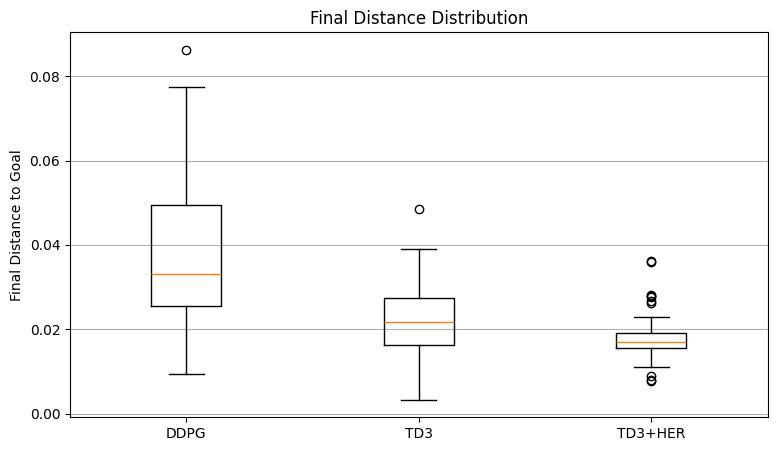

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
plt.figure(figsize=(9, 5))

plt.boxplot(
    [dist_ddpg, dist_td3, dist_td3_her],
    labels=["DDPG", "TD3", "TD3+HER"]
)

plt.ylabel("Final Distance to Goal")
plt.title("Final Distance Distribution")
plt.grid(True, axis="y")
plt.show()

#Noise robustness Comparison

Now evaluates DDPG, TD3, and TD3+HER across increasing observation-noise levels and plots how each models success rate degrades as noise gets larger.

First load in the models.

In [ ]:
ddpg_mod = DDPG.load("DDPG", env=make_modified_env())
td3_mod = TD3.load("TD3", env=make_modified_env())
td3_her = TD3.load("TD3_HER", env=make_modified_env())

Wrapping the env in a DummyVecEnv.
Wrapping the env in a DummyVecEnv.
Wrapping the env in a DummyVecEnv.


Define the noise levels

In [ ]:
noise_levels = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1, 1.5, 2]

Create evaluate function that recreate environment with different noise levels.

In [ ]:
def eval_with_noise(model, sigma, episodes=20):
    env = make_modified_env(noise_std=sigma, reward_type="sparse")
    success, _ = evaluate_policy(
        env,
        lambda obs: model.predict(obs, deterministic=True)[0],
        episodes=episodes
    )
    return success

Generate the success rate for different noise levels.

In [ ]:
ddpg_scores = [eval_with_noise(ddpg_mod, s) for s in noise_levels]
td3_scores = [eval_with_noise(td3_mod, s) for s in noise_levels]
td3_her_scores = [eval_with_noise(td3_her, s) for s in noise_levels]

Success rate: 70.0%, Average distance: 0.04
Success rate: 60.0%, Average distance: 0.05
Success rate: 60.0%, Average distance: 0.04
Success rate: 80.0%, Average distance: 0.04
Success rate: 55.0%, Average distance: 0.05
Success rate: 70.0%, Average distance: 0.04
Success rate: 60.0%, Average distance: 0.05
Success rate: 50.0%, Average distance: 0.06
Success rate: 25.0%, Average distance: 0.08
Success rate: 35.0%, Average distance: 0.07
Success rate: 20.0%, Average distance: 0.06
Success rate: 15.0%, Average distance: 0.08
Success rate: 10.0%, Average distance: 0.10
Success rate: 5.0%, Average distance: 0.15
Success rate: 100.0%, Average distance: 0.02
Success rate: 100.0%, Average distance: 0.02
Success rate: 100.0%, Average distance: 0.02
Success rate: 100.0%, Average distance: 0.02
Success rate: 100.0%, Average distance: 0.02
Success rate: 100.0%, Average distance: 0.02
Success rate: 100.0%, Average distance: 0.02
Success rate: 90.0%, Average distance: 0.03
Success rate: 100.0%, Aver

Plot the success rate for varying noise.

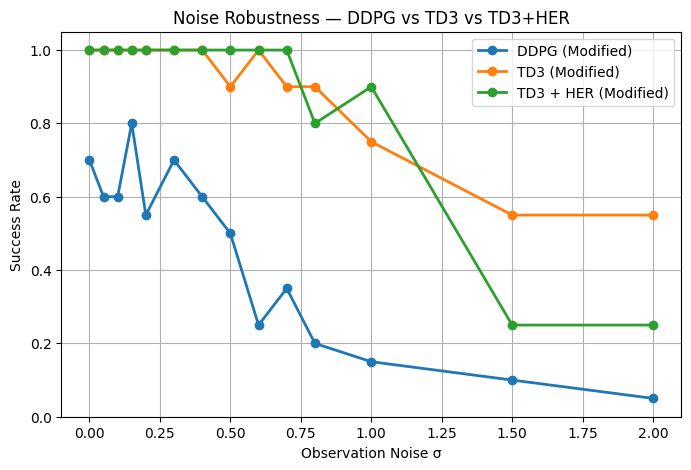

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(noise_levels, ddpg_scores, marker="o", linewidth=2, label="DDPG (Modified)")
plt.plot(noise_levels, td3_scores, marker="o", linewidth=2, label="TD3 (Modified)")
plt.plot(noise_levels, td3_her_scores, marker="o", linewidth=2, label="TD3 + HER (Modified)")

plt.xlabel("Observation Noise σ")
plt.ylabel("Success Rate")
plt.title("Noise Robustness — DDPG vs TD3 vs TD3+HER")
plt.grid(True)
plt.legend()
plt.ylim(0, 1.05)

plt.show()

#Abalition Comparison

Evaluate DDPG, TD3, and TD3+HER across four environment conditions (dense clean, sparse clean, dense noisy, sparse noisy) and plots their success rates side-by-side in a combined ablation bar chart.

First load the trained models.

In [ ]:
ddpg_mod = DDPG.load("DDPG", env=make_modified_env())
td3_mod = TD3.load("TD3", env=make_modified_env())
td3_her = TD3.load("TD3_HER", env=make_modified_env())

Wrapping the env in a DummyVecEnv.
Wrapping the env in a DummyVecEnv.
Wrapping the env in a DummyVecEnv.


Define the 4 envionrment types.

In [ ]:
def env_dense_clean():
    return gym.make("FetchReach-v4", reward_type="dense")

def env_sparse_clean():
    return gym.make("FetchReach-v4", reward_type="sparse")

def env_dense_noisy():
    env = gym.make("FetchReach-v4", reward_type="dense")
    return ObservationNoiseWrapper(env, noise_std=0.15)

def env_sparse_noisy():
    env = gym.make("FetchReach-v4", reward_type="sparse")
    return ObservationNoiseWrapper(env, noise_std=0.15)

envs = [
    env_dense_clean,
    env_sparse_clean,
    env_dense_noisy,
    env_sparse_noisy
]

labels = ["Dense/Clean", "Sparse/Clean", "Dense/Noise", "Sparse/Noise"]

Write a new evaluation function that creates the enviornment internally, runs the model directly, and returns only succes.

In [ ]:
def evaluate_success(model, env_fn, episodes=20):
    env = env_fn()
    success = 0
    for _ in range(episodes):
        obs, info = env.reset()
        done = False

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

        success += info.get("is_success", 0)

    return success / episodes

Evaluate all 3 models in all 4 environemnts.

In [ ]:
ddpg_scores = [evaluate_success(ddpg_mod, fn) for fn in envs]
td3_scores  = [evaluate_success(td3_mod,  fn) for fn in envs]
td3_her_scores = [evaluate_success(td3_her, fn) for fn in envs]

Plot the combined bar chart.

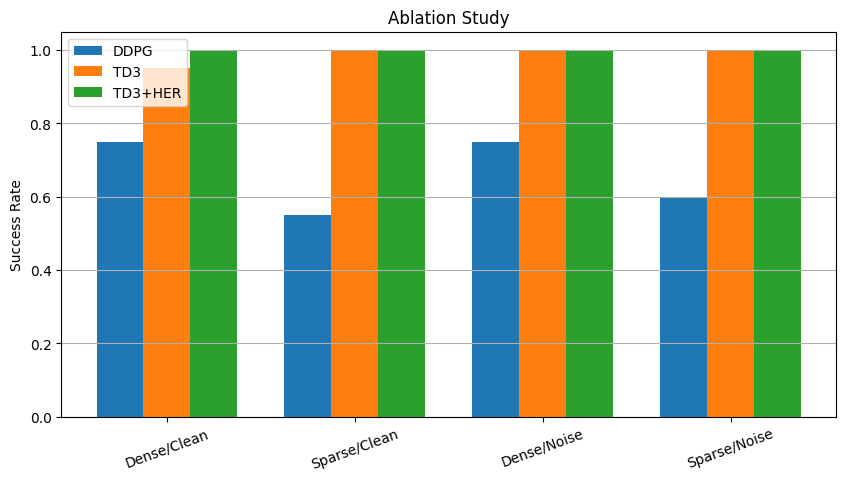

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(10, 5))

plt.bar(x - width, ddpg_scores, width, label="DDPG")
plt.bar(x,        td3_scores,  width, label="TD3")
plt.bar(x + width, td3_her_scores, width, label="TD3+HER")

plt.xticks(x, labels, rotation=20)
plt.ylabel("Success Rate")
plt.title("Ablation Study")
plt.ylim(0, 1.05)
plt.grid(True, axis="y")
plt.legend()

plt.show()


#Stability Comparison

Stability is essentially how consistent the policy is over multiple episodes.

We define an evaluation function that returns success mean and success standard deviation over multiple episodes.

In [ ]:
def evaluate_policy_stats(env_fn, model, episodes=20):
    successes = []
    env = env_fn()

    for _ in range(episodes):
        obs, info = env.reset()
        done = False

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

        successes.append(info.get("is_success", 0))

    successes = np.array(successes)
    return successes.mean(), successes.std()

Load the models

In [ ]:
ddpg_mod = DDPG.load("DDPG", env=make_modified_env())
td3_mod  = TD3.load("TD3", env=make_modified_env())
td3_her  = TD3.load("TD3_HER", env=make_modified_env())

Wrapping the env in a DummyVecEnv.
Wrapping the env in a DummyVecEnv.
Wrapping the env in a DummyVecEnv.


Evaluate stability for each model.

In [ ]:
models = {
    "DDPG": ddpg_mod,
    "TD3": td3_mod,
    "TD3+HER": td3_her
}

means = []
stds = []

for name, model in models.items():
    mean, std = evaluate_policy_stats(make_modified_env, model, episodes=50)
    means.append(mean)
    stds.append(std)
    print(f"{name}: mean={mean:.3f}, std={std:.3f}")

DDPG: mean=0.720, std=0.449
TD3: mean=0.980, std=0.140
TD3+HER: mean=1.000, std=0.000


Plot the stability for each model.

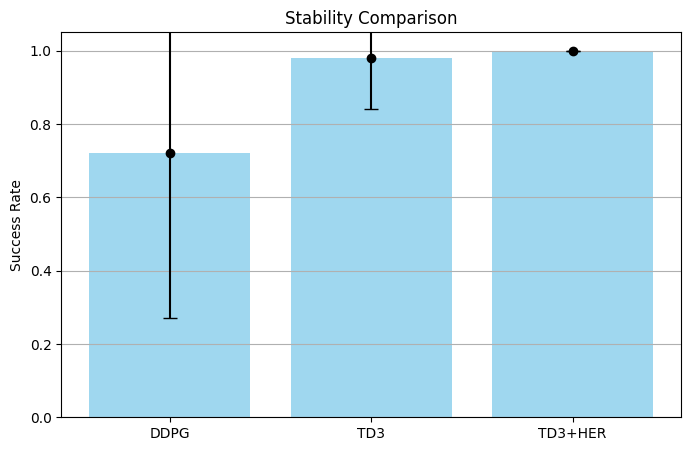

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
plt.figure(figsize=(8, 5))

x = np.arange(len(models))

plt.bar(x, means, color="skyblue", alpha=0.8)
plt.errorbar(x, means, yerr=stds, fmt="o", color="black", capsize=5)

plt.xticks(x, list(models.keys()))
plt.ylim(0, 1.05)
plt.ylabel("Success Rate")
plt.title("Stability Comparison")

plt.grid(True, axis="y")
plt.show()

Save all the files and graph data we generated.

In [ ]:
!zip -r all_files.zip /content

  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/config_sentinel (stored 0%)
  adding: content/.config/default_configs.db (deflated 98%)
  adding: content/.config/gce (stored 0%)
  adding: content/.config/.last_opt_in_prompt.yaml (stored 0%)
  adding: content/.config/configurations/ (stored 0%)
  adding: content/.config/configurations/config_default (deflated 15%)
  adding: content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (deflated 97%)
  adding: content/.config/.last_update_check.json (deflated 23%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2025.11.20/ (stored 0%)
  adding: content/.config/logs/2025.11.20/14.30.45.231815.log (deflated 57%)
  adding: content/.config/logs/2025.11.20/14.30.35.382199.log (deflated 87%)
  adding: content/.config/logs/2025.11.20/14.30.45.937471.log (deflated 56%)
  adding: content/.config/logs/2025.11.20/14.30.04.285207.log (deflated 93%)
  adding: 

#Self Implamantation of TD3

As an extension we implement TD3 ourselves to understand which of the 3 imporvements of TD3 over DDPG make its succes rate significantly higher. Since this code is quite large and an extension of the current notebook, we leave it in a seperate file: https://colab.research.google.com/drive/18RhIy972ZO5jNVwnMk54h6-J686hC8t5?usp=sharing